# Customer Churn & Retention Analysis

## 1. Project Objective 

The objective of this project is to analyze customer churn patterns, identify customer characteristics associated with higher churn, and develop machine learning models to support customer retention analysis.

The project combines exploratory data analysis, customer risk segmentation, and machine learning to provide both analytical and business-oriented insights.

## 2. Data Loading and Initial Exploration

The Telco Customer Churn dataset contains customer demographic, service, contract, payment, and billing information. The target variable is `Churn`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("churn_dataset.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:

df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3. Data Cleaning

The initial dataset contains 7,043 customers and 21 variables. The `TotalCharges` column is stored as text and contains blank values, so it needs to be converted to numeric format before analysis.

The `customerID` column is an identifier and does not provide useful predictive information, so it will be removed.

In [9]:
df['TotalCharges'].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df = df.dropna(subset=['TotalCharges'])
df.shape

(7032, 21)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the distribution of customer churn and identify customer characteristics associated with higher churn.

The analysis focuses on contract type, customer tenure, monthly charges, and payment method.

### 4.1 Overall Churn Distribution

The overall churn distribution is examined to understand the proportion of customers who stayed with the company versus those who churned.

In [14]:
churn_counts = df['Churn'].value_counts()

print(churn_counts)
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


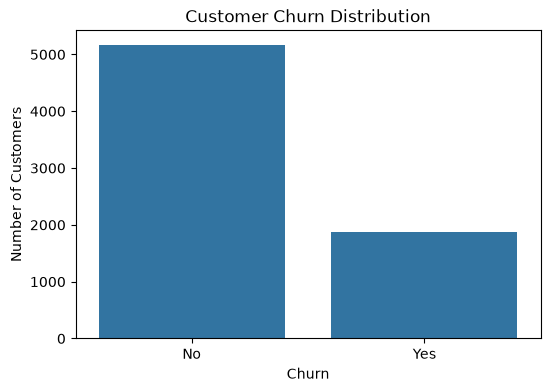

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

### 4.2 Churn by Contract Type

Churn rates are compared across different contract types to identify whether contract duration is associated with customer churn.

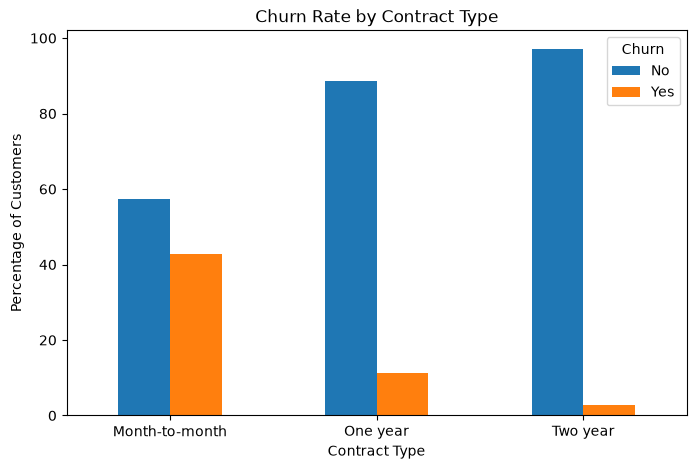

In [16]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn
contract_churn.plot(
    kind='bar',
    stacked=False,
    figsize=(8, 5)
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')

plt.show()

### 4.3 Churn by Customer Tenure

Customer tenure is analyzed to determine whether newer or longer-tenured customers show different observed churn rates.

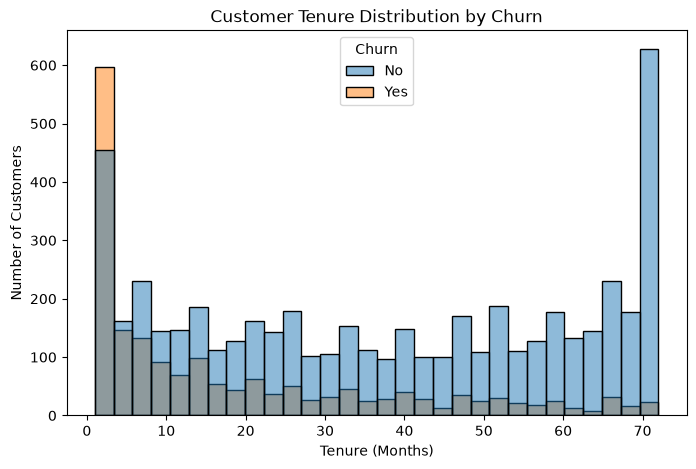

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=False
)

plt.title('Customer Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

In [20]:
bins = [0, 12, 24, 36, 48, 60, 72]

labels = [
    '0-12 months',
    '13-24 months',
    '25-36 months',
    '37-48 months',
    '49-60 months',
    '61-72 months'
]

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.321839,47.678161
13-24 months,71.289062,28.710938
25-36 months,78.365385,21.634615
37-48 months,80.971129,19.028871
49-60 months,85.576923,14.423077
61-72 months,93.390192,6.609808


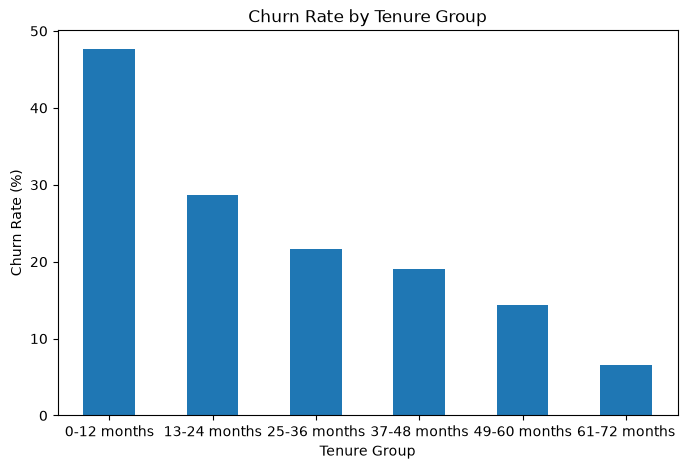

In [21]:
tenure_churn['Yes'].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [28]:
df = df.drop('TenureGroup', axis=1)

### 4.4 Churn and Monthly Charges

Monthly charges are compared between customers who churned and those who remained to examine whether higher monthly billing is associated with customer churn.

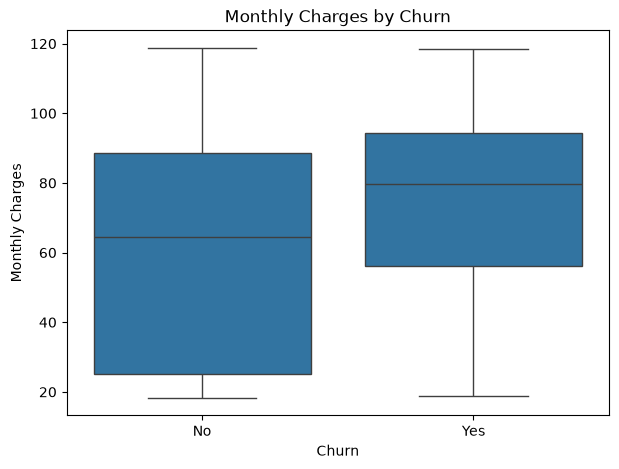

In [22]:
df.groupby('Churn')['MonthlyCharges'].mean()

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

In [23]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### 4.5 Churn by Payment Method

Churn rates are compared across different payment methods to identify payment groups with substantially different observed churn levels.

In [25]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn



Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


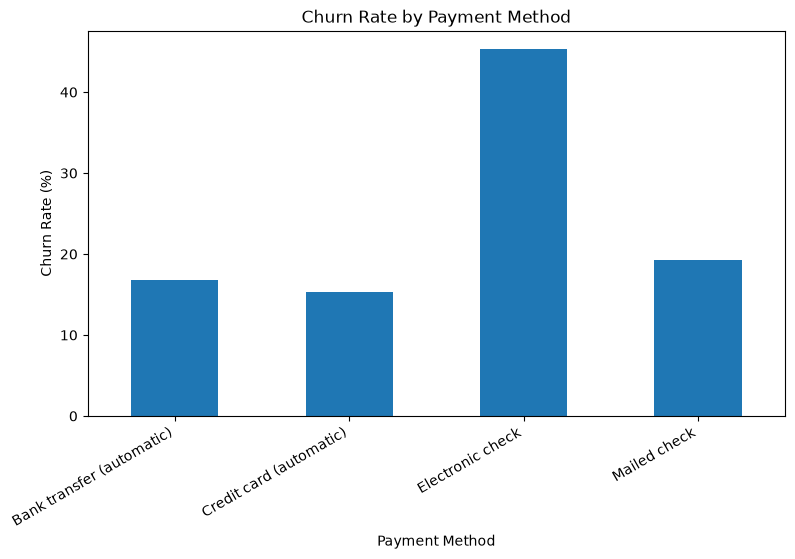

In [26]:
payment_churn['Yes'].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30, ha='right')

plt.show()

## 5. Machine Learning

Machine learning models are used to classify customers based on their likelihood of churn. The target variable is `Churn`, where 1 represents churn and 0 represents no churn.

Two classification models are evaluated:

- Logistic Regression
- Random Forest

In [34]:
# Reload original dataset
df = pd.read_csv("churn_dataset.csv")

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Remove customer ID
df = df.drop('customerID', axis=1)

# Convert Churn to 0/1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})


X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nChurn values:")
print(y.value_counts())
print("\nMissing values in y:", y.isnull().sum())

X shape: (7032, 19)
y shape: (7032,)

Churn values:
Churn
0    5163
1    1869
Name: count, dtype: int64

Missing values in y: 0


### 5.1 Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. Stratified sampling is used to maintain a similar churn distribution in both sets.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


In [36]:
categorical_cols = X_train.select_dtypes(include='object').columns
numerical_cols = X_train.select_dtypes(exclude='object').columns

print("Categorical columns:")
print(list(categorical_cols))

print("\nNumerical columns:")
print(list(numerical_cols))

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/var/folders/k6/6xcxf2ns6n70879yfqpfybnw0000gn/T/ipykernel_86596/518924175.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include='object').columns


### 5.2 Feature Encoding

Categorical variables are converted into numerical representations using one-hot encoding, while numerical variables are retained for model training.

In [37]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [38]:
X_train_final = np.hstack([
    X_train[numerical_cols].values,
    X_train_encoded
])

X_test_final = np.hstack([
    X_test[numerical_cols].values,
    X_test_encoded
])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (5625, 45)
Final testing shape: (1407, 45)


### 5.3 Feature Scaling

Standardization is applied to the encoded features before training Logistic Regression so that numerical variables are placed on a comparable scale.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

## 6. Logistic Regression

Logistic Regression is used as an interpretable baseline model for binary customer churn classification. It estimates the probability that a customer belongs to the churn class.

In [40]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

### 6.1 Logistic Regression Evaluation

The model is evaluated using accuracy, precision, recall, and F1-score. Recall is particularly relevant for churn analysis because missing an actual churner may result in a missed retention opportunity.

In [42]:
y_pred = logistic_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:",cm)

Accuracy : 0.8038379530916845
Precision: 0.6475903614457831
Recall   : 0.5748663101604278
F1 Score : 0.6090651558073654
Confusion matrix: [[916 117]
 [159 215]]


## 7. Random Forest

Random Forest is evaluated as a tree-based ensemble model that can capture nonlinear relationships between customer characteristics and churn.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [44]:
rf_pred = rf_model.predict(X_test_final)

### 7.1 Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression to allow a consistent comparison between the two approaches.

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

Accuracy : 0.7846481876332623
Precision: 0.6228373702422145
Recall   : 0.48128342245989303
F1 Score : 0.5429864253393665
[[924 109]
 [194 180]]


## 8. Model Comparison

Both models are evaluated using the same test dataset and the same evaluation metrics. This allows their performance to be compared consistently.

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 80.38% | 64.76% | 57.49% | 60.91% |
| Random Forest | 78.46% | 62.28% | 48.13% | 54.30% |

Logistic Regression achieved higher accuracy, precision, recall, and F1-score on the test data. It was therefore selected as the final model for this project.

In addition to its performance, Logistic Regression provides interpretable coefficients, which is useful for understanding factors associated with customer churn.

### 8.1 Churn Factors from Logistic Regression

The coefficients of the Logistic Regression model are examined to understand which customer characteristics are associated with higher or lower predicted churn, while recognizing that these associations do not imply causation.

In [46]:
#get feature names
feature_names = list(numerical_cols) + list(
    encoder.get_feature_names_out(categorical_cols)
)

print("Number of features:", len(feature_names))

Number of features: 45


In [47]:
# Get Logistic Regression coefficients
coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

#sort them
feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
3,TotalCharges,0.642389
16,InternetService_Fiber optic,0.410096
36,Contract_Month-to-month,0.321072
32,StreamingTV_Yes,0.178917
35,StreamingMovies_Yes,0.172174
18,OnlineSecurity_No,0.117788
14,MultipleLines_Yes,0.116149
43,PaymentMethod_Electronic check,0.113467
27,TechSupport_No,0.108296
26,DeviceProtection_Yes,0.086252


In [48]:
feature_importance.tail(10)

,Feature,Coefficient
28,TechSupport_No internet service,-0.115387
31,StreamingTV_No internet service,-0.115387
34,StreamingMovies_No internet service,-0.115387
22,OnlineBackup_No internet service,-0.115387
17,InternetService_No,-0.115387
19,OnlineSecurity_No internet service,-0.115387
38,Contract_Two year,-0.326914
15,InternetService_DSL,-0.328964
2,MonthlyCharges,-0.918004
1,tenure,-1.348901


In [49]:
top_features = feature_importance.copy()

top_features['AbsCoefficient'] = top_features['Coefficient'].abs()

top_features = top_features.sort_values(
    by='AbsCoefficient',
    ascending=False
).head(10)

top_features

,Feature,Coefficient,AbsCoefficient
1,tenure,-1.348901,1.348901
2,MonthlyCharges,-0.918004,0.918004
3,TotalCharges,0.642389,0.642389
16,InternetService_Fiber optic,0.410096,0.410096
15,InternetService_DSL,-0.328964,0.328964
38,Contract_Two year,-0.326914,0.326914
36,Contract_Month-to-month,0.321072,0.321072
32,StreamingTV_Yes,0.178917,0.178917
35,StreamingMovies_Yes,0.172174,0.172174
18,OnlineSecurity_No,0.117788,0.117788


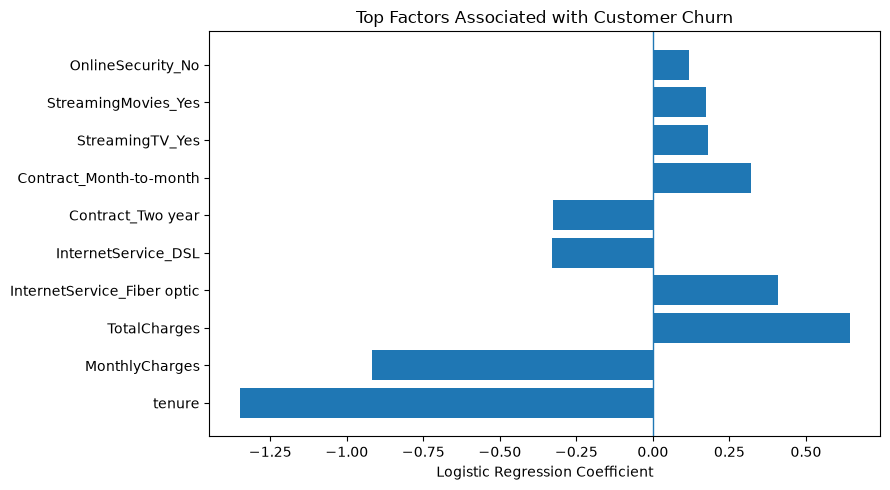

In [50]:
plt.figure(figsize=(9, 5))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(0, linewidth=1)

plt.title('Top Factors Associated with Customer Churn')
plt.xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.show()

## 9. Customer Risk Segmentation

A simple rule-based risk score is created using three customer characteristics identified during the exploratory analysis:

- Tenure of 12 months or less
- Month-to-month contract
- Electronic check payment method

Each characteristic contributes one point to the customer's risk score. This creates a transparent segmentation from 0 to 3, allowing customers with multiple observed risk characteristics to be identified for potential retention attention.

In [51]:
df['RiskScore'] = 0

df.loc[df['tenure'] <= 12, 'RiskScore'] += 1

df.loc[df['Contract'] == 'Month-to-month', 'RiskScore'] += 1

df.loc[df['PaymentMethod'] == 'Electronic check', 'RiskScore'] += 1

In [52]:
risk_analysis = df.groupby('RiskScore')['Churn'].agg(
    Customers='count',
    ChurnRate='mean'
)

risk_analysis['ChurnRate'] = risk_analysis['ChurnRate'] * 100

risk_analysis

,Customers,ChurnRate
RiskScore,,
0,2485,5.150905
1,1633,19.657073
2,1960,41.734694
3,954,63.102725


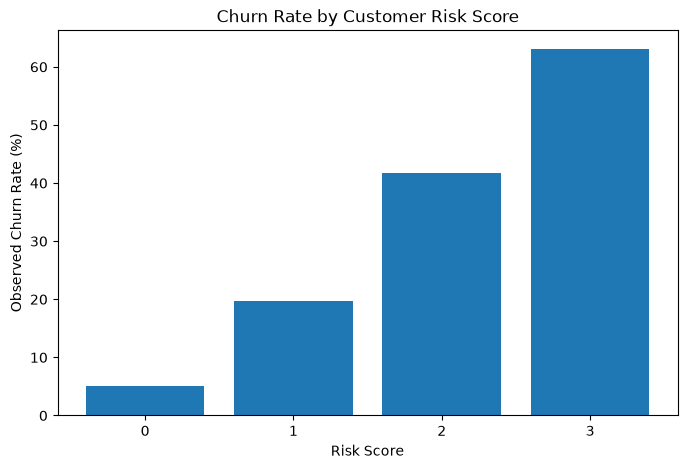

In [53]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_analysis.index.astype(str),
    risk_analysis['ChurnRate']
)

plt.title('Churn Rate by Customer Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Observed Churn Rate (%)')

plt.show()

### 9.1 Risk Segment Findings

The observed churn rate increases as the number of identified risk characteristics increases.

Customers with a risk score of 3 have an observed churn rate of 63.1%, compared with 5.2% for customers with a risk score of 0.

This segmentation is an analytical indicator rather than a machine-learning prediction or a causal measure.

## 10. Business Recommendations

Based on the observed churn patterns, the following retention actions can be considered:

1. **Month-to-month customers:** Encourage longer-term contracts through suitable incentives or contract benefits.

2. **New customers:** Strengthen onboarding and early-stage engagement during the first year, when observed churn is highest.

3. **Electronic check customers:** Investigate the payment experience and consider convenient automatic payment options.

4. **High-risk segments:** Prioritize customers showing multiple identified risk characteristics for targeted retention efforts.

These recommendations are based on observed associations in the dataset and should be validated with additional customer and business information before implementation.

## 11. Conclusion

This project analyzed customer churn using exploratory data analysis, machine learning, and risk segmentation.

The analysis identified contract type, customer tenure, payment method, and monthly charges as important churn-related patterns. Logistic Regression performed better than Random Forest on the test dataset and was selected as the final model.

The resulting analysis provides a practical framework for identifying higher-risk customer segments and supporting targeted retention decisions.